<a href="https://colab.research.google.com/github/atkarekrishna89-alt/Fake-News-Detection/blob/main/fake_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Fake News Detection
### Using NLP (TF-IDF) + Naïve Bayes & Logistic Regression

**Dataset:** [Fake and Real News Dataset — Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset)  
**Files needed:** `Fake.csv` and `True.csv`

## Step 1 — Install Dependencies

In [ ]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn --quiet

## Step 2 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))
print('All libraries imported successfully ✅')

All libraries imported successfully ✅


In [ ]:
%%writefile requirements.txt
nltk
scikit-learn
pandas
numpy
matplotlib
seaborn

## Step 3 — Upload Dataset (Colab)

Run this cell to upload `Fake.csv` and `True.csv` directly in Google Colab.  
> **Local users:** skip this cell — just place the CSVs in the same folder as this notebook.

In [ ]:
from google.colab import files
print('Please upload Fake.csv and True.csv')
uploaded = files.upload()

Please upload Fake.csv and True.csv


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


## Step 4 — Load & Label Dataset

In [ ]:
fake = pd.read_csv('Fake.csv')
real = pd.read_csv('True.csv')

fake['label'] = 0   # Fake = 0
real['label'] = 1   # Real = 1

print(f'Fake articles : {len(fake):,}')
print(f'Real articles : {len(real):,}')
fake.head(3)

Fake articles : 23,481
Real articles : 21,417


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0


## Step 5 — Merge & Shuffle Datasets

Total samples : 44,898

Label distribution:
label
Fake    23481
Real    21417
Name: count, dtype: int64


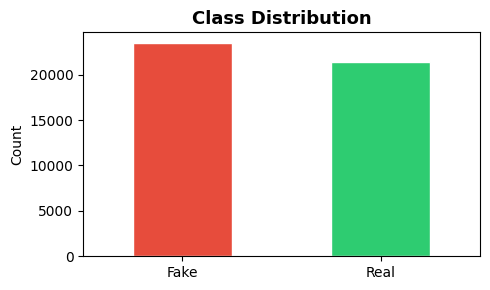

In [ ]:
df = pd.concat([fake, real], ignore_index=True)
df = df[['text', 'label']].dropna()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total samples : {len(df):,}')
print('\nLabel distribution:')
print(df['label'].value_counts().rename({0: 'Fake', 1: 'Real'}))

fig, ax = plt.subplots(figsize=(5, 3))
df['label'].value_counts().rename({0: 'Fake', 1: 'Real'}).plot(
    kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='white', ax=ax
)
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_xticklabels(['Fake', 'Real'], rotation=0)
plt.tight_layout()
plt.show()

## Step 6 — Text Preprocessing

In [ ]:
def preprocess(text: str) -> str:
    """Lowercase -> remove punctuation/numbers -> remove stopwords."""
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = [t for t in text.split() if t not in STOP_WORDS]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

print('Sample raw text:')
print(df['text'].iloc[0][:200])
print('\nAfter preprocessing:')
print(df['clean_text'].iloc[0][:200])

Sample raw text:
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative s

After preprocessing:
st century wire says ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocative statements judge jeanine pirro show recently d


## Step 7 — TF-IDF Vectorization + Train/Test Split

In [ ]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)



In [ ]:
print(f'Train size : {X_train_tfidf.shape[0]:,}')
print(f'Test size  : {X_test_tfidf.shape[0]:,}')
print(f'Features   : {X_train_tfidf.shape[1]:,}')

Train size : 35,918
Test size  : 8,980
Features   : 50,000


## Step 8 — Train Models

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
print('Naive Bayes trained ✅')

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
print('Logistic Regression trained ✅')

Naive Bayes trained ✅
Logistic Regression trained ✅


## Step 9 — Evaluate Models


---------------------------------------------
  Model    : Naive Bayes
  Accuracy : 96.19%
---------------------------------------------
              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      4696
        Real       0.96      0.96      0.96      4284

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



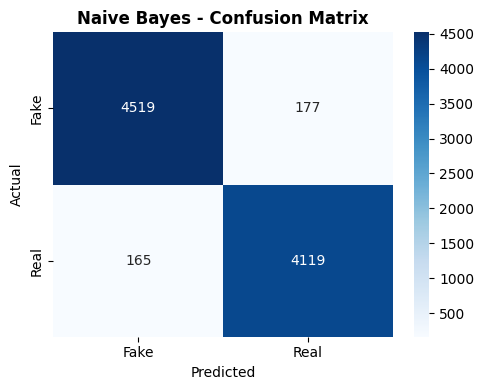


---------------------------------------------
  Model    : Logistic Regression
  Accuracy : 99.03%
---------------------------------------------
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



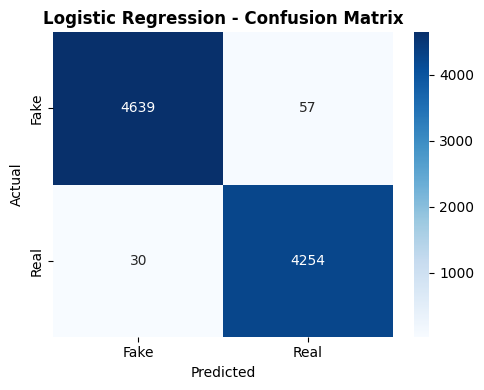

In [ ]:
def evaluate(name, model, X_te, y_te):
    preds = model.predict(X_te)
    acc   = accuracy_score(y_te, preds)
    cm    = confusion_matrix(y_te, preds)

    print(f'\n{"-"*45}')
    print(f'  Model    : {name}')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'{"-"*45}')
    print(classification_report(y_te, preds, target_names=['Fake', 'Real']))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Fake', 'Real'],
        yticklabels=['Fake', 'Real']
    )
    plt.title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    return acc

acc_nb = evaluate('Naive Bayes',         nb, X_test_tfidf, y_test)
acc_lr = evaluate('Logistic Regression', lr, X_test_tfidf, y_test)

## Step 10 — Compare & Select Best Model

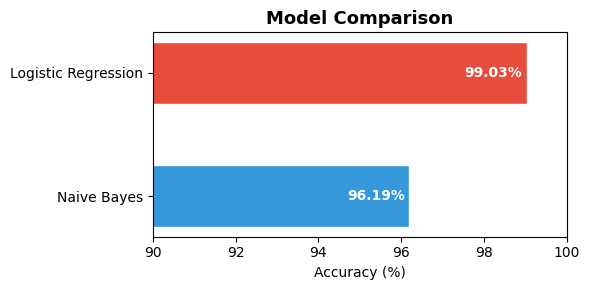


🏆 Best model: Logistic Regression (99.03%)


In [ ]:
results = pd.DataFrame({
    'Model'   : ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [acc_nb, acc_lr]
})

fig, ax = plt.subplots(figsize=(6, 3))
colors = ['#3498db', '#e74c3c']
bars = ax.barh(results['Model'], results['Accuracy'] * 100,
               color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, results['Accuracy']):
    ax.text(val * 100 - 1.5, bar.get_y() + bar.get_height() / 2,
            f'{val*100:.2f}%', va='center', color='white', fontweight='bold')
ax.set_xlim(90, 100)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_model = lr if acc_lr >= acc_nb else nb
best_name  = 'Logistic Regression' if acc_lr >= acc_nb else 'Naive Bayes'
print(f'\n🏆 Best model: {best_name} ({max(acc_lr, acc_nb)*100:.2f}%)')

## Step 11 — Save Best Model with Pickle

In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('model.pkl saved ✅')
print('tfidf.pkl saved ✅')
print('\nDownload these two files and place them alongside app.py to run the Streamlit UI.')

model.pkl saved ✅
tfidf.pkl saved ✅

Download these two files and place them alongside app.py to run the Streamlit UI.


## Step 12 — Download Saved Files (Colab only)

In [ ]:
from google.colab import files
files.download('model.pkl')
files.download('tfidf.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 13 — Quick Inference Test

In [ ]:
def predict_news(text: str) -> str:
    clean  = preprocess(text)
    vector = tfidf.transform([clean])
    pred   = best_model.predict(vector)[0]
    proba  = best_model.predict_proba(vector)[0]
    label  = 'Real News ✅' if pred == 1 else 'Fake News 🚨'
    conf   = proba[pred]
    return f'{label}  (confidence: {conf*100:.1f}%)'

samples = [
    'Scientists confirm new vaccine is 95% effective after large clinical trial.',
    'BREAKING: President secretly replaced by lizard alien, sources confirm!!!'
]

for s in samples:
    print(f'Text   : {s}')
    print(f'Result : {predict_news(s)}')
    print()

Text   : Scientists confirm new vaccine is 95% effective after large clinical trial.
Result : Fake News 🚨  (confidence: 73.1%)

Text   : BREAKING: President secretly replaced by lizard alien, sources confirm!!!
Result : Fake News 🚨  (confidence: 90.4%)



---
## ✅ Done!

**Next steps:**
1. Download `model.pkl` and `tfidf.pkl` (Step 12)
2. Place them alongside `app.py`
3. Run `streamlit run app.py`

```bash
pip install -r requirements.txt
streamlit run app.py
```